In [31]:
import pandas as pd 
import numpy as np 
# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("../files/merchant_fill_nonulls.csv")

In [33]:
df.head(2)

,Unnamed: 0,title,price,retail_price,units_sold,uses_ad_boosts,rating_sold,rating_count,badge_local_product,badge_product_quality,...,mean_product_prices,mean_retail_prices,mean_product_ratings_count,discount_percentage,seller_reputation,rating_four_count,rating_three_count,rating_two_count,rating_one_count,rating_five_count
0,0,2020 Summer Vintage Flamingo Print Pajamas Se...,16.0,14,100,No,3.76,54,No,Buena,...,16.00,14.00,54.0,14.29,Buena,8.0,10.0,1.0,9.0,26.0
1,1,SSHOUSE Summer Casual Sleeveless Soirée Party ...,8.0,22,20000,Si,3.45,6135,No,Buena,...,5.68,10.33,1057.0,-63.64,Regular,1027.0,1118.0,644.0,1077.0,2269.0


In [34]:
df.columns

Index(['Unnamed: 0', 'title', 'price', 'retail_price', 'units_sold',
       'uses_ad_boosts', 'rating_sold', 'rating_count', 'badge_local_product',
       'badge_product_quality', 'badge_fast_shipping', 'tags', 'product_color',
       'product_variation_size_id', 'shipping_option_name',
       'shipping_option_price', 'shipping_is_express', 'countries_shipped_to',
       'inventory_total', 'origin_country', 'merchant_name',
       'merchant_info_subtitle', 'merchant_rating_count', 'merchant_id',
       'product_url', 'product_id', 'listed_products', 'total_units_sold',
       'mean_units_sold_per_product', 'rating_employee',
       'merchant_ratings_count', 'mean_product_prices', 'mean_retail_prices',
       'mean_product_ratings_count', 'discount_percentage',
       'seller_reputation', 'rating_four_count', 'rating_three_count',
       'rating_two_count', 'rating_one_count', 'rating_five_count'],
      dtype='object')

In [35]:
df.shape

(1573, 41)

In [36]:
df.describe()

,Unnamed: 0,price,retail_price,units_sold,rating_sold,rating_count,shipping_option_price,countries_shipped_to,inventory_total,merchant_rating_count,...,merchant_ratings_count,mean_product_prices,mean_retail_prices,mean_product_ratings_count,discount_percentage,rating_four_count,rating_three_count,rating_two_count,rating_one_count,rating_five_count
count,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1.573000e+03,...,1.573000e+03,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000
mean,786.000000,8.325372,23.288620,4339.005086,3.820896,889.659250,2.345200,40.456453,49.821360,2.649583e+04,...,2.649583e+04,8.325601,23.288589,889.686586,-26.060668,179.599476,134.549738,63.711387,95.735602,442.263743
std,454.230301,3.932030,30.357863,9356.539302,0.515374,1983.928834,1.024371,20.301203,2.562799,7.847446e+04,...,7.847446e+04,3.588461,28.750732,1716.377853,40.883828,394.742028,307.197043,149.162023,210.989239,966.071776
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,6.000000,1.000000,0.000000e+00,...,0.000000e+00,1.000000,1.000000,0.000000,-96.930000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,393.000000,5.810000,7.000000,100.000000,3.550000,24.000000,2.000000,31.000000,50.000000,1.987000e+03,...,1.987000e+03,6.000000,7.000000,38.000000,-72.350000,5.000000,4.000000,2.000000,4.000000,13.000000
50%,786.000000,8.000000,10.000000,1000.000000,3.850000,150.000000,2.000000,40.000000,50.000000,7.936000e+03,...,7.936000e+03,8.000000,11.000000,279.000000,-5.830000,35.000000,26.000000,12.000000,22.000000,86.000000
75%,1179.000000,11.000000,26.000000,5000.000000,4.110000,855.000000,3.000000,43.000000,50.000000,2.456400e+04,...,2.456400e+04,10.250000,26.000000,957.000000,12.500000,179.599476,134.549738,63.711387,95.735602,442.263743
max,1572.000000,49.000000,252.000000,100000.000000,5.000000,20744.000000,12.000000,140.000000,50.000000,2.174765e+06,...,2.174765e+06,49.000000,252.000000,20744.000000,18.200000,4152.000000,3658.000000,2003.000000,2789.000000,11548.000000


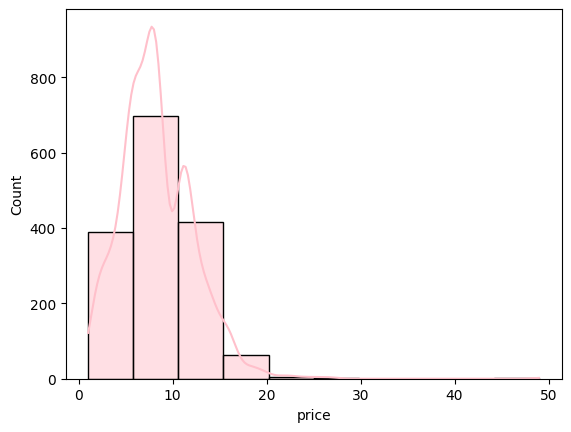

In [37]:
#1.¿Cómo se distribuyen los precios de los productos?
# histograma
sns.histplot(data=df, x="price",color="pink", bins=10, kde=True);
#Resultado:  la mayoria esta entre 0 y 20

In [38]:
df(["badge_product_quality"]).count(axis=1)


TypeError: 'DataFrame' object is not callable

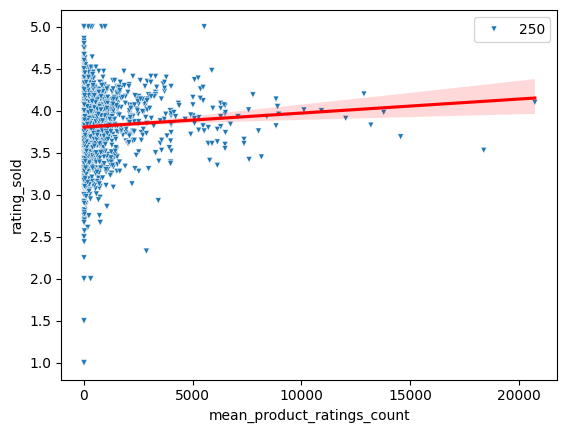

In [48]:
#2. Cual es la relacion entre  precio y calificacion promedio de los productos
sns.scatterplot(data=df,
                x="mean_product_ratings_count",
                y="rating_sold",
                marker="v",
                size=250);
sns.regplot(x='mean_product_ratings_count', y='rating_sold', data=df, scatter=False, color='red');
#plt.xlabel("Edad",fontsize=15);


In [39]:
#3.que porcentaje de productos tiene el distintivo producto local
#pieplot
df_local=df.groupby("badge_local_product")["product_id"].count().reset_index()
df_local

,badge_local_product,product_id
0,No,1544
1,Si,29


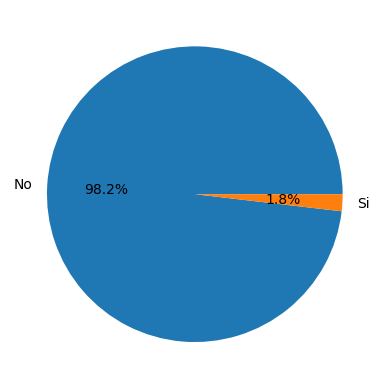

In [40]:
plt.pie("product_id",labels="badge_local_product",data=df_local,autopct="%1.1f%%");

In [44]:
#4.Que porcentaje tiene el distintivo buena calidad de producto
df_quality=df.groupby("badge_product_quality")["product_id"].count().reset_index()
df_quality

,badge_product_quality,product_id
0,Buena,1456
1,Excelente,117


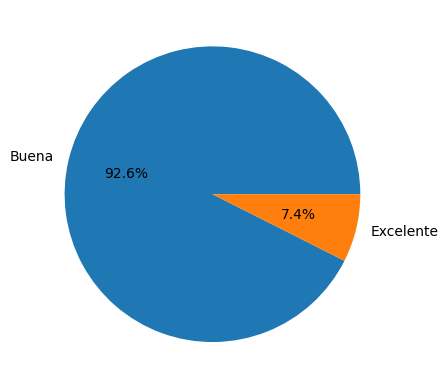

In [47]:
plt.pie("product_id",labels="badge_product_quality",data=df_quality,autopct="%1.1f%%");

C:\Users\Luzma\AppData\Local\Temp\ipykernel_19852\3572688434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,


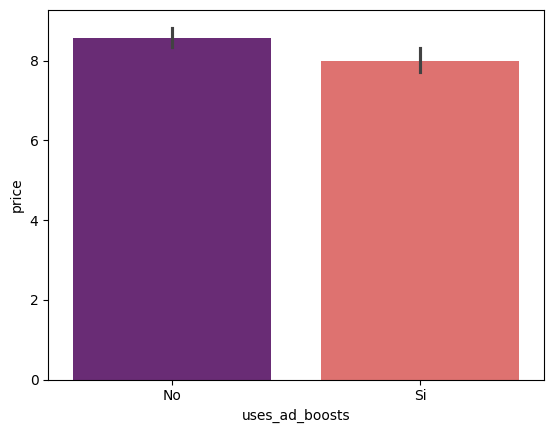

In [55]:
#5.¿Cómo se distribuyen los precios de los productos en función de 
# si se utilizan anuncios promocionales (uses_ad_boosts) o no


sns.barplot(data=df,
            x="uses_ad_boosts",
            y="price",
            palette="magma",
           );